In [1]:
import numpy as np
from scipy.signal import find_peaks
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')
import numpy as np
import networkx as nx

from plots import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions from merged module
from plots import (
    std_plot_coordination_histograms,
    plot_graph_structure,
    std_plot_cluster_size_distribution,
    std_plot_3d_graph_components,
    std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

from shell_utils import (
    get_species_densities_from_data,
    calculate_coordination_number,
    calculate_coordination_number_vs_r,
    plot_coordination_number_vs_r,
    plot_multiple_cn_vs_r,
    save_cn_r_data,
    analyze_bond_coordination,
    plot_bond_coordination_histograms
)


In [2]:
# get_species_densities_from_data function moved to shell_utils.py


In [3]:
# calculate_coordination_number function moved to shell_utils.py


In [4]:
# Example usage:
# CN = calculate_coordination_number(r_values, g_values, rho_j)
# 
# Or with manual integration limits:
# CN = calculate_coordination_number(r_values, g_values, rho_j, r1=0.0, r2=3.5)


In [5]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

In [6]:
pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow(
    pipeline=pipe,
    # disable_pair=("Na", "Cl"),  # Keep all bonds for construction
    metals=["Pu"],  # Only Pu for cluster analysis, ignoring Na nodes
    anion="Cl",
    rdf_samples=rdf_samples,
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)

Loaded trajectory with 14615 frames
Standardized plotting style configured
Pairwise cutoffs: {('Pu', 'Cl'): 3.9354099581612783, ('Pu', 'Na'): 6.419025016922944, ('Pu', 'Pu'): 6.2014689534593925, ('Cl', 'Pu'): 3.9354099581612783, ('Cl', 'Na'): 4.190203891248118, ('Cl', 'Cl'): 6.049791833679462, ('Na', 'Pu'): 6.419025016922944, ('Na', 'Cl'): 4.190203891248118, ('Na', 'Na'): 6.3406478383858165}


In [7]:
names = result["names"]
sizes = result["sizes"]
cluster_ids = result["cluster_ids"]
data0 = result["data"]
G = result["graph"]


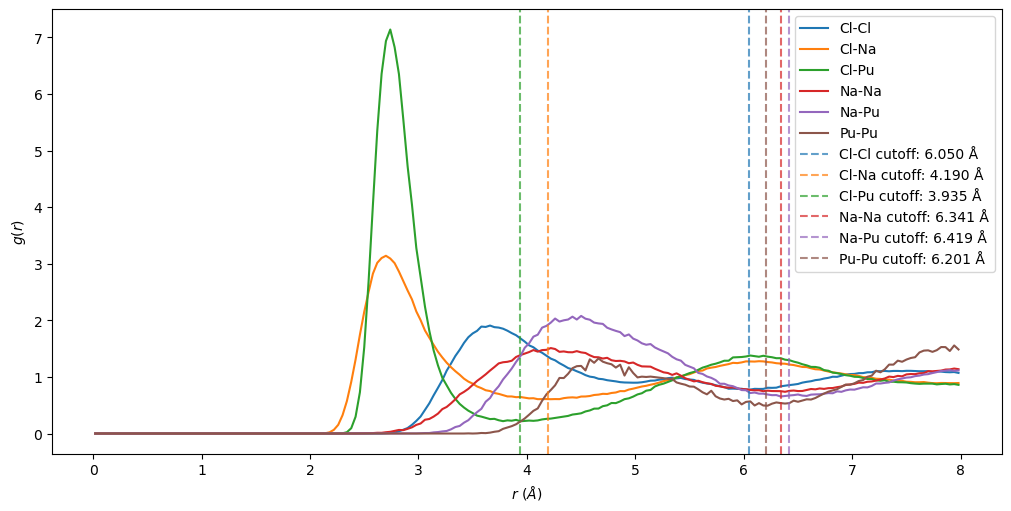

In [8]:
plot_rdfs(result["rdf"], cutoffs=cutoffs,figsize=(10, 5))

In [9]:
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))

{np.str_('Cl'): np.float64(0.01915186620320566),
 np.str_('Na'): np.float64(0.009012642919155605),
 np.str_('Pu'): np.float64(0.0033797410946833518)}

In [10]:
result["rdf"].keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'r'])

In [11]:
calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=3.26)

np.float64(5.814762194518516)

In [12]:
# analyze_bond_coordination and plot_bond_coordination_histograms functions moved to shell_utils.py

# Test the coordination analysis with current data
print("=" * 60)
print("BOND-BASED COORDINATION HISTOGRAM ANALYSIS")
print("=" * 60)

# Analyze coordination using bond cutoffs
coord_data = analyze_bond_coordination(data0, names, pair_cutoffs=cutoffs)

# Plot coordination histograms for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data and any(any(counts) for counts in coord_data[species].values()):
        print(f"\nPlotting coordination histogram for {species}:")
        plot_bond_coordination_histograms(coord_data, species, " (Bond-based Analysis)")
    else:
        print(f"No coordination data available for {species}")

print("\n" + "=" * 60)
print("BOND-BASED COORDINATION ANALYSIS COMPLETE")
print("=" * 60)


BOND-BASED COORDINATION HISTOGRAM ANALYSIS
Analyzing coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]


KeyboardInterrupt: 

In [ ]:
cutoffs

{('Pu', 'Cl'): 3.9354099581612783,
 ('Pu', 'Na'): 6.419025016922944,
 ('Pu', 'Pu'): 6.2014689534593925,
 ('Cl', 'Pu'): 3.9354099581612783,
 ('Cl', 'Na'): 4.190203891248118,
 ('Cl', 'Cl'): 6.049791833679462,
 ('Na', 'Pu'): 6.419025016922944,
 ('Na', 'Cl'): 4.190203891248118,
 ('Na', 'Na'): 6.3406478383858165}

In [ ]:
CN_pu_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
CN_pu_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Pu', 'Na')])
CN_pu_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Pu-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Pu', 'Pu')])

/tmp/ipykernel_1361997/2209525467.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [ ]:
CN_na_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Na', 'Cl')])
CN_na_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Na', 'Na')])
CN_na_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Na', 'Pu')])

/tmp/ipykernel_1361997/2209525467.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [ ]:
CN_cl_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Cl"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Cl', 'Cl')])
CN_cl_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Cl', 'Na')])
CN_cl_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Cl', 'Pu')])

/tmp/ipykernel_1361997/2209525467.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [ ]:
# Create a comprehensive comparison table of coordination numbers
import pandas as pd

print("=" * 80)
print("COORDINATION NUMBER COMPARISON: RDF INTEGRATION vs HISTOGRAM ANALYSIS")
print("=" * 80)

# Extract coordination numbers from RDF integration
rdf_cn_values = {
    'Pu-Cl': CN_pu_cl,
    'Pu-Na': CN_pu_na, 
    'Pu-Pu': CN_pu_pu,
    'Na-Cl': CN_na_cl,
    'Na-Na': CN_na_na,
    'Na-Pu': CN_na_pu,
    'Cl-Cl': CN_cl_cl,
    'Cl-Na': CN_cl_na,
    'Cl-Pu': CN_cl_pu
}

# Extract coordination numbers from histogram analysis
histogram_cn_values = {}

# Calculate mean coordination numbers from histogram data
for central_sp in ['Pu', 'Na', 'Cl']:
    if central_sp in coord_data:
        for neighbor_sp in ['Pu', 'Na', 'Cl']:
            if neighbor_sp in coord_data[central_sp] and coord_data[central_sp][neighbor_sp]:
                counts = coord_data[central_sp][neighbor_sp]
                mean_cn = np.mean(counts)
                std_cn = np.std(counts)
                pair_key = f"{central_sp}-{neighbor_sp}"
                histogram_cn_values[pair_key] = {
                    'mean': mean_cn,
                    'std': std_cn,
                    'count': len(counts)
                }

# Create comparison table
comparison_data = []
for pair in sorted(rdf_cn_values.keys()):
    rdf_val = rdf_cn_values[pair]
    
    if pair in histogram_cn_values:
        hist_mean = histogram_cn_values[pair]['mean']
        hist_std = histogram_cn_values[pair]['std']
        hist_count = histogram_cn_values[pair]['count']
        difference = rdf_val - hist_mean
        percent_diff = (difference / hist_mean) * 100 if hist_mean != 0 else 0
    else:
        hist_mean = "N/A"
        hist_std = "N/A"
        hist_count = "N/A"
        difference = "N/A"
        percent_diff = "N/A"
    
    comparison_data.append({
        'Pair': pair,
        'RDF Integration': f"{rdf_val:.3f}",
        'Histogram Mean': f"{hist_mean:.3f}" if isinstance(hist_mean, (int, float)) else hist_mean,
        'Histogram Std': f"{hist_std:.3f}" if isinstance(hist_std, (int, float)) else hist_std,
        'Histogram Count': hist_count,
        'Difference': f"{difference:.3f}" if isinstance(difference, (int, float)) else difference,
        'Percent Diff': f"{percent_diff:.1f}%" if isinstance(percent_diff, (int, float)) else percent_diff
    })

# Create DataFrame and display
df_comparison = pd.DataFrame(comparison_data)
print("\nDetailed Comparison Table:")
print(df_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Calculate summary statistics for pairs where both methods have data
valid_pairs = []
for pair in rdf_cn_values.keys():
    if pair in histogram_cn_values:
        valid_pairs.append(pair)

if valid_pairs:
    differences = []
    percent_diffs = []
    
    for pair in valid_pairs:
        rdf_val = rdf_cn_values[pair]
        hist_val = histogram_cn_values[pair]['mean']
        diff = rdf_val - hist_val
        percent_diff = (diff / hist_val) * 100 if hist_val != 0 else 0
        differences.append(diff)
        percent_diffs.append(percent_diff)
    
    print(f"Number of comparable pairs: {len(valid_pairs)}")
    print(f"Mean absolute difference: {np.mean(np.abs(differences)):.3f}")
    print(f"Mean absolute percent difference: {np.mean(np.abs(percent_diffs)):.1f}%")
    print(f"Max absolute difference: {np.max(np.abs(differences)):.3f}")
    print(f"Max absolute percent difference: {np.max(np.abs(percent_diffs)):.1f}%")

print("\n" + "=" * 80)
print("CUTOFF VALUES USED")
print("=" * 80)
for pair, cutoff in cutoffs.items():
    print(f"{pair[0]}-{pair[1]}: {cutoff:.3f} Å")

print("\n" + "=" * 80)
print("SPECIES DENSITIES")
print("=" * 80)
densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))
for species, density in densities.items():
    print(f"{species}: {density:.6f} atoms/Å³")


COORDINATION NUMBER COMPARISON: RDF INTEGRATION vs HISTOGRAM ANALYSIS

Detailed Comparison Table:
 Pair RDF Integration Histogram Mean Histogram Std  Histogram Count Difference Percent Diff
Cl-Cl          16.844         14.487         3.483             2176      2.357        16.3%
Cl-Na           2.899          2.622         1.170             2176      0.277        10.6%
Cl-Pu           1.156          1.061         0.643             2176      0.095         9.0%
Na-Cl           6.161          5.571         1.414             1024      0.590        10.6%
Na-Na           8.887          7.588         2.453             1024      1.299        17.1%
Na-Pu           3.905          3.298         1.333             1024      0.607        18.4%
Pu-Cl           6.553          6.013         1.204              384      0.540         9.0%
Pu-Na          10.412          8.794         2.559              384      1.618        18.4%
Pu-Pu           2.126          1.802         1.140              384      0

In [ ]:
# Calculate CN_*_any (total coordination for each central species)
print("=" * 60)
print("CALCULATING CN_*_any (Total Coordination for Each Central Species)")
print("=" * 60)

# Method 1: Sum individual CN values
CN_pu_any_rdf = CN_pu_cl + CN_pu_na + CN_pu_pu
CN_na_any_rdf = CN_na_cl + CN_na_na + CN_na_pu  
CN_cl_any_rdf = CN_cl_cl + CN_cl_na + CN_cl_pu

print("From RDF Integration (sum of individual CNs):")
print(f"CN_Pu_any = CN_Pu_Cl + CN_Pu_Na + CN_Pu_Pu = {CN_pu_cl:.3f} + {CN_pu_na:.3f} + {CN_pu_pu:.3f} = {CN_pu_any_rdf:.3f}")
print(f"CN_Na_any = CN_Na_Cl + CN_Na_Na + CN_Na_Pu = {CN_na_cl:.3f} + {CN_na_na:.3f} + {CN_na_pu:.3f} = {CN_na_any_rdf:.3f}")
print(f"CN_Cl_any = CN_Cl_Cl + CN_Cl_Na + CN_Cl_Pu = {CN_cl_cl:.3f} + {CN_cl_na:.3f} + {CN_cl_pu:.3f} = {CN_cl_any_rdf:.3f}")

#

CALCULATING CN_*_any (Total Coordination for Each Central Species)
From RDF Integration (sum of individual CNs):
CN_Pu_any = CN_Pu_Cl + CN_Pu_Na + CN_Pu_Pu = 6.553 + 10.412 + 2.126 = 19.091
CN_Na_any = CN_Na_Cl + CN_Na_Na + CN_Na_Pu = 6.161 + 8.887 + 3.905 = 18.952
CN_Cl_any = CN_Cl_Cl + CN_Cl_Na + CN_Cl_Pu = 16.844 + 2.899 + 1.156 = 20.900


In [ ]:
from bondmodifier_utils import canonical_cluster_workflow_rdfs_only

In [ ]:
# Comprehensive coordination number analysis for all x & T combinations
import glob
import re
import json
import pickle
from pathlib import Path
from tqdm.auto import tqdm
print("=" * 80)
print("COMPREHENSIVE COORDINATION NUMBER + RDF ANALYSIS")
print("=" * 80)

# Get all dump files
file_list = glob.glob('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x*/T*/dump.lammpstrj')
print(f"Found {len(file_list)} files to process")

# Initialize results dictionary
coordination_results = {}
rdf_data_all = {}

# Process each file
for i in tqdm(range(len(file_list))):
    infile = file_list[i]
    print(f"\nProcessing file {i+1}/{len(file_list)}: {infile}")
    
    # Extract x and T from file path
    path_parts = infile.split('/')
    x_part = None
    T_part = None
    
    for part in path_parts:
        if part.startswith('x') and '.' in part:
            x_part = part
        elif part.startswith('T') and 'K' in part:
            T_part = part
    
    if not x_part or not T_part:
        print(f"  Warning: Could not extract x and T from {infile}")
        continue
    
    # Extract numerical values
    x_match = re.search(r'x(\d+\.?\d*)', x_part)
    T_match = re.search(r'T(\d+)K', T_part)
    
    if not x_match or not T_match:
        print(f"  Warning: Could not parse x and T values from {x_part}, {T_part}")
        continue
    
    x_val = float(x_match.group(1))
    T_val = int(T_match.group(1))
    
    print(f"  Processing x={x_val}, T={T_val}K")
    
    try:
        # Load pipeline
        pipe = import_file(infile, multiple_frames=True)
        print(f"    Loaded {pipe.source.num_frames} frames")
        
        # Generate RDFs and cutoffs
        result = canonical_cluster_workflow_rdfs_only(
            pipeline=pipe,
            rdf_samples=100,
        )
        
        rdf_data = result["rdf"]
        cutoffs = result["pair_cutoffs"]
        
        # Get species densities
        densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))
        
        # Store RDF data (convert numpy arrays to lists for JSON serialization)
        rdf_data_serializable = {}
        for key, value in rdf_data.items():
            if isinstance(value, np.ndarray):
                rdf_data_serializable[key] = value.tolist()
            else:
                rdf_data_serializable[key] = value
        
        rdf_data_all[(x_val, T_val)] = {
            'x': x_val,
            'T': T_val,
            'file': infile,
            'rdf_data': rdf_data_serializable,
            'cutoffs': cutoffs,
            'densities': densities
        }
        
        # Calculate individual coordination numbers
        cn_values = {}
        
        # Individual CN calculations
        cn_pairs = [
            ('Pu', 'Cl'), ('Pu', 'Na'), ('Pu', 'Pu'),
            ('Na', 'Cl'), ('Na', 'Na'), ('Na', 'Pu'),
            ('Cl', 'Cl'), ('Cl', 'Na'), ('Cl', 'Pu')
        ]
        
        for central, neighbor in cn_pairs:
            try:
                # Create alphabetically sorted RDF key (e.g., Pu-Cl becomes Cl-Pu)
                rdf_key = '-'.join(sorted([central, neighbor]))
                if rdf_key in rdf_data and neighbor in densities:
                    cn_val = calculate_coordination_number(
                        rdf_data["r"], 
                        rdf_data[rdf_key], 
                        densities[neighbor],
                        r1=0.0, 
                        r2=cutoffs[(central, neighbor)]
                    )
                    cn_values[f"CN_{central}_{neighbor}"] = cn_val
                else:
                    cn_values[f"CN_{central}_{neighbor}"] = np.nan
            except Exception as e:
                print(f"    Error calculating CN_{central}_{neighbor}: {e}")
                cn_values[f"CN_{central}_{neighbor}"] = np.nan
        
        # Calculate total coordination numbers (CN_*_any)
        cn_values["CN_Pu_any"] = cn_values["CN_Pu_Cl"] + cn_values["CN_Pu_Na"] + cn_values["CN_Pu_Pu"]
        cn_values["CN_Na_any"] = cn_values["CN_Na_Cl"] + cn_values["CN_Na_Na"] + cn_values["CN_Na_Pu"]
        cn_values["CN_Cl_any"] = cn_values["CN_Cl_Cl"] + cn_values["CN_Cl_Na"] + cn_values["CN_Cl_Pu"]
        
        # Store results
        coordination_results[(x_val, T_val)] = {
            'file': infile,
            'x': x_val,
            'T': T_val,
            'cutoffs': cutoffs,
            'densities': densities,
            'coordination_numbers': cn_values
        }
        
        print(f"    Successfully calculated coordination numbers and stored RDF data")
        
    except Exception as e:
        print(f"    Error processing {infile}: {e}")
        # Store NaN values for failed cases
        cn_values = {}
        for central in ['Pu', 'Na', 'Cl']:
            for neighbor in ['Pu', 'Na', 'Cl']:
                cn_values[f"CN_{central}_{neighbor}"] = np.nan
        cn_values["CN_Pu_any"] = np.nan
        cn_values["CN_Na_any"] = np.nan
        cn_values["CN_Cl_any"] = np.nan
        
        coordination_results[(x_val, T_val)] = {
            'file': infile,
            'x': x_val,
            'T': T_val,
            'cutoffs': None,
            'densities': None,
            'coordination_numbers': cn_values
        }
        
        # Store empty RDF data for failed cases
        rdf_data_all[(x_val, T_val)] = {
            'x': x_val,
            'T': T_val,
            'file': infile,
            'rdf_data': None,
            'cutoffs': None,
            'densities': None
        }

print(f"\nCompleted processing {len(coordination_results)} files")

# Create summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

# Sort by x, then T
sorted_results = sorted(coordination_results.items(), key=lambda x: (x[0][0], x[0][1]))

# Create DataFrame for easy viewing
import pandas as pd

summary_data = []
for (x, T), data in sorted_results:
    cn_data = data['coordination_numbers']
    row = {
        'x': x,
        'T': T,
        'CN_Pu_Cl': cn_data['CN_Pu_Cl'],
        'CN_Pu_Na': cn_data['CN_Pu_Na'],
        'CN_Pu_Pu': cn_data['CN_Pu_Pu'],
        'CN_Na_Cl': cn_data['CN_Na_Cl'],
        'CN_Na_Na': cn_data['CN_Na_Na'],
        'CN_Na_Pu': cn_data['CN_Na_Pu'],
        'CN_Cl_Cl': cn_data['CN_Cl_Cl'],
        'CN_Cl_Na': cn_data['CN_Cl_Na'],
        'CN_Cl_Pu': cn_data['CN_Cl_Pu'],
        'CN_Pu_any': cn_data['CN_Pu_any'],
        'CN_Na_any': cn_data['CN_Na_any'],
        'CN_Cl_any': cn_data['CN_Cl_any']
    }
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False, float_format='%.3f'))

# Save coordination numbers to JSON file
cn_output_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/coordination_numbers_all_x_T.json'
with open(cn_output_file, 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    json_data = {}
    for (x, T), data in coordination_results.items():
        json_data[f"x{x}_T{T}"] = {
            'x': float(x),
            'T': int(T),
            'file': data['file'],
            'coordination_numbers': {k: float(v) if not np.isnan(v) else None for k, v in data['coordination_numbers'].items()}
        }
    json.dump(json_data, f, indent=2)

# Save RDF data to JSON file
rdf_output_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/rdf_data_all_x_T.json'
with open(rdf_output_file, 'w') as f:
    json.dump(rdf_data_all, f, indent=2)

# Also save RDF data as pickle for better numpy array preservation
rdf_pickle_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/rdf_data_all_x_T.pkl'
with open(rdf_pickle_file, 'wb') as f:
    pickle.dump(rdf_data_all, f)

print(f"\nResults saved to:")
print(f"  Coordination numbers: {cn_output_file}")
print(f"  RDF data (JSON): {rdf_output_file}")
print(f"  RDF data (Pickle): {rdf_pickle_file}")
print(f"Total files processed: {len(coordination_results)}")
print(f"Successful calculations: {sum(1 for data in coordination_results.values() if data['cutoffs'] is not None)}")
print(f"Failed calculations: {sum(1 for data in coordination_results.values() if data['cutoffs'] is None)}")

# Show RDF data structure
print(f"\nRDF data structure:")
if rdf_data_all:
    sample_key = list(rdf_data_all.keys())[0]
    sample_data = rdf_data_all[sample_key]
    if sample_data['rdf_data'] is not None:
        print(f"  Sample RDF keys: {list(sample_data['rdf_data'].keys())}")
        print(f"  R-axis length: {len(sample_data['rdf_data']['r'])}")
        print(f"  RDF pairs: {[k for k in sample_data['rdf_data'].keys() if k != 'r' and k != 'complete']}")
    else:
        print("  No RDF data available in sample")


COMPREHENSIVE COORDINATION NUMBER + RDF ANALYSIS
Found 76 files to process


  0%|          | 0/76 [00:00<?, ?it/s]


Processing file 1/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1200K/dump.lammpstrj
  Processing x=0.4, T=1200K
    Loaded 25057 frames


/tmp/ipykernel_1361997/2209525467.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


    Successfully calculated coordination numbers and stored RDF data

Processing file 2/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1100K/dump.lammpstrj
  Processing x=0.4, T=1100K
    Loaded 24588 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 3/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T800K/dump.lammpstrj
  Processing x=0.4, T=800K
    Loaded 23530 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 4/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1300K/dump.lammpstrj
  Processing x=0.4, T=1300K
    Loaded 25431 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 5/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1000K/dump.lammpstrj
  Processing x=0.4, T=1000K
    Loaded 24515 frames
    Successfully calculated coordination numbers and stored RDF da

TypeError: keys must be str, int, float, bool or None, not tuple

In [ ]:
from matplotlib import pyplot as plt

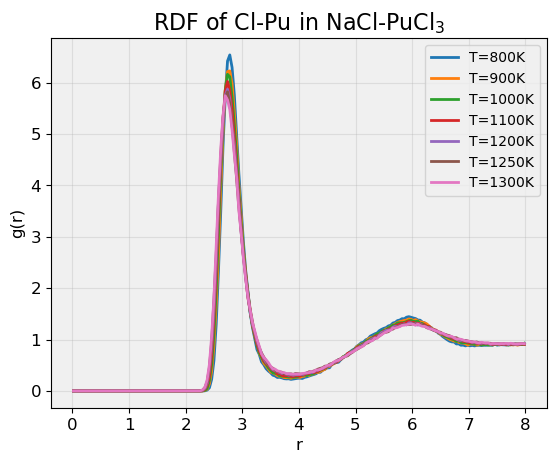

In [ ]:
pucl_rdfs=dict()
pucl_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        pucl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Cl-Pu']
        pucl_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(pucl_rdfs.keys()):
    plt.plot(pucl_rs[key], pucl_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Cl-Pu in NaCl-PuCl$_3$')
plt.show()


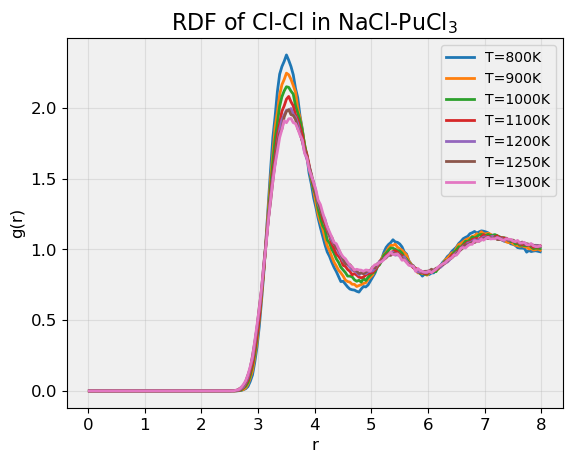

In [ ]:
clcl_rdfs=dict()
clcl_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        clcl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Cl-Cl']
        clcl_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(clcl_rdfs.keys()):
    plt.plot(clcl_rs[key], clcl_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Cl-Cl in NaCl-PuCl$_3$')
plt.show()


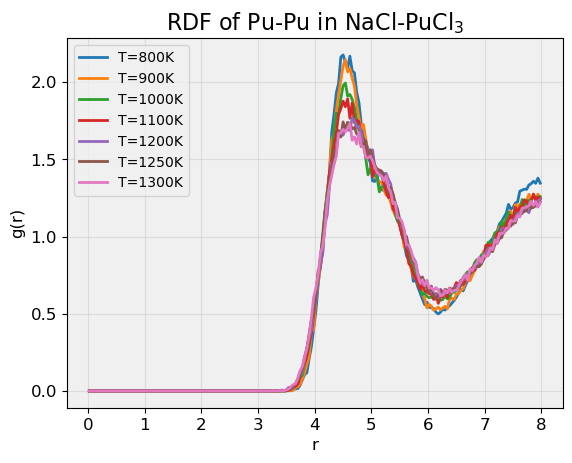

In [ ]:
pupu_rdfs=dict()
pupu_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        pupu_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Pu-Pu']
        pupu_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(pupu_rdfs.keys()):
    plt.plot(pupu_rs[key], pupu_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Pu-Pu in NaCl-PuCl$_3$')
plt.show()


In [ ]:
rdf_data_all[(0.67, 800)].keys()

dict_keys(['x', 'T', 'file', 'rdf_data', 'cutoffs', 'densities'])

In [ ]:
rdf_data_all[(0.67, 800)]['rdf_data'].keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'r'])

In [ ]:

dpucl_rdfs=dict()
# dpucl_rs=dict()
dpucl_CN=dict()
dpucl_densities=dict()

for key in rdf_data_all.keys():
    if key[0] == 0.67:
        dpucl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']
        dpucl_CN[key[1]]=dict()
        dpucl_densities[key[1]]=rdf_data_all[key]['densities']


        CN_pu_cl=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Cl-Pu"], dpucl_densities[key[1]]["Cl"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        CN_pu_na=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Na-Pu"], dpucl_densities[key[1]]["Na"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        CN_pu_pu=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Pu-Pu"], dpucl_densities[key[1]]["Pu"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        dpucl_CN[key[1]]["CN_Pu_Cl"]=CN_pu_cl
        dpucl_CN[key[1]]["CN_Pu_Na"]=CN_pu_na
        dpucl_CN[key[1]]["CN_Pu_Pu"]=CN_pu_pu
        dpucl_CN[key[1]]["CN_Pu_any"]=CN_pu_cl+CN_pu_na+CN_pu_pu



TypeError: unsupported operand type(s) for -: 'list' and 'float'

dpucl_densities

In [ ]:
infile = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T800K/dump.lammpstrj'
pipe = import_file(infile, multiple_frames=True)
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))



{np.str_('Cl'): np.float64(0.023959924398009456),
 np.str_('Na'): np.float64(0.0034228463425727794),
 np.str_('Pu'): np.float64(0.006845692685145559)}

In [ ]:
infile = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T1200K/dump.lammpstrj'
pipe = import_file(infile, multiple_frames=True)
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))



{np.str_('Cl'): np.float64(0.021543845362447748),
 np.str_('Na'): np.float64(0.003077692194635393),
 np.str_('Pu'): np.float64(0.006155384389270786)}

In [ ]:
# calculate_coordination_number_vs_r function moved to shell_utils.py


In [ ]:
# plot_coordination_number_vs_r and plot_multiple_cn_vs_r functions moved to shell_utils.py


In [ ]:
# Example: Calculate CN(r) for Pu-Cl pair using current data
print("=" * 60)
print("COORDINATION NUMBER AS A FUNCTION OF R")
print("=" * 60)

# Get current data
current_rdf = result["rdf"]
current_cutoffs = result["pair_cutoffs"]
current_densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))

# Calculate CN(r) for Pu-Cl pair
r_pucl, cn_pucl = calculate_coordination_number_vs_r(
    current_rdf["r"], 
    current_rdf["Cl-Pu"], 
    current_densities["Cl"],
    r_max=current_cutoffs[('Pu', 'Cl')]
)

print(f"Pu-Cl coordination number at cutoff ({current_cutoffs[('Pu', 'Cl')]:.3f} Å): {cn_pucl[-1]:.3f}")
print(f"R range: {r_pucl[0]:.3f} to {r_pucl[-1]:.3f} Å")
print(f"Number of points: {len(r_pucl)}")

# Plot the result
plot_coordination_number_vs_r(r_pucl, cn_pucl, "Pu-Cl", r_max=current_cutoffs[('Pu', 'Cl')])


COORDINATION NUMBER AS A FUNCTION OF R
Pu-Cl coordination number at cutoff (3.898 Å): 7.405
R range: 0.020 to 3.900 Å
Number of points: 98


/tmp/ipykernel_278266/1787466056.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cn_values[i] = np.trapz(integrand, r_integration)


<Axes: title={'center': 'Coordination Number vs Radial Distance: Pu-Cl'}, xlabel='Radial Distance r (Å)', ylabel='Coordination Number CN(r)'>


CN(r) FOR ALL SPECIES PAIRS
Pu-Cl   : Final CN =  7.405 at r = 3.900 Å
Pu-Na   : Final CN =  3.349 at r = 6.340 Å
Pu-Pu   : Final CN =  2.831 at r = 6.140 Å
Na-Cl   : Final CN =  6.821 at r = 4.140 Å
Na-Na   : Final CN =  2.974 at r = 6.260 Å
Na-Pu   : Final CN =  6.697 at r = 6.340 Å
Cl-Cl   : Final CN = 18.941 at r = 6.060 Å
Cl-Na   : Final CN =  0.974 at r = 4.140 Å
Cl-Pu   : Final CN =  2.116 at r = 3.900 Å

Plotting CN(r) for 9 species pairs...


/tmp/ipykernel_278266/1787466056.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cn_values[i] = np.trapz(integrand, r_integration)


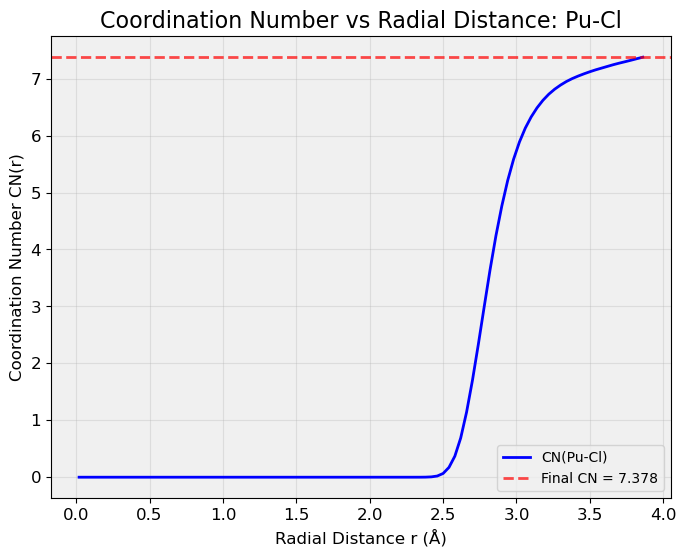

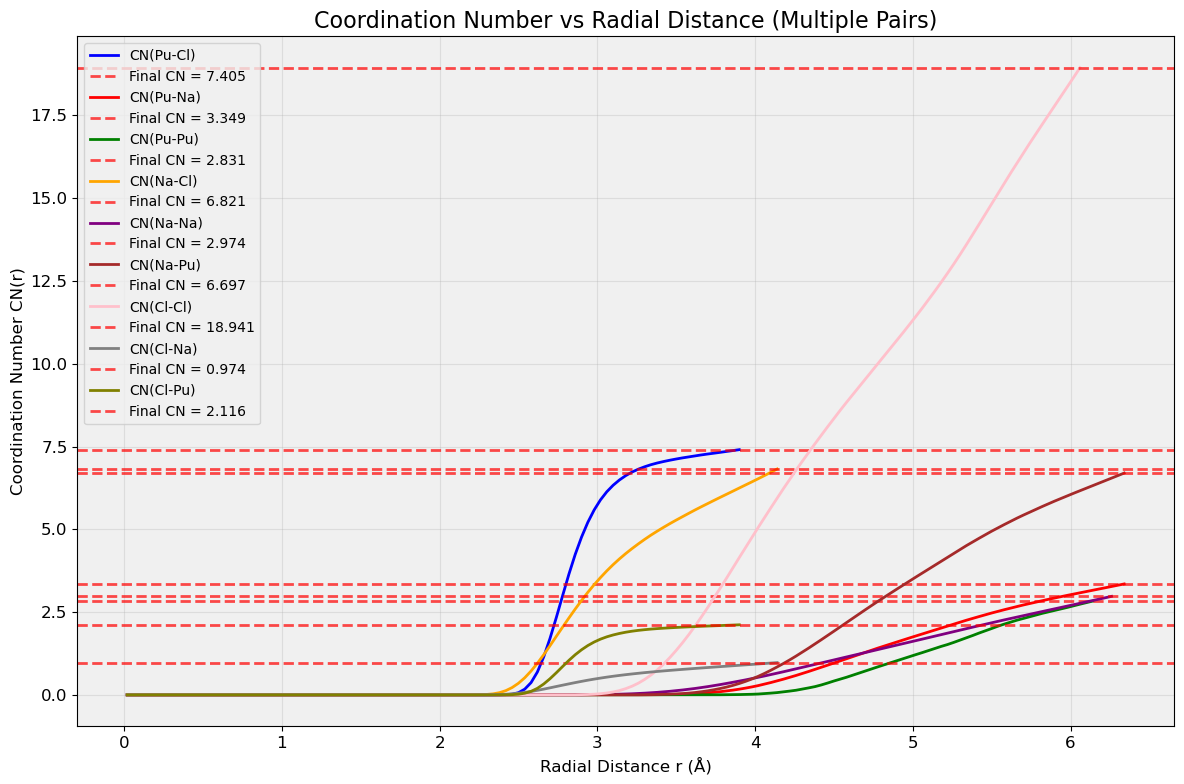

In [ ]:
# Calculate CN(r) for all species pairs
print("\n" + "=" * 60)
print("CN(r) FOR ALL SPECIES PAIRS")
print("=" * 60)

cn_r_data = {}

# Define all species pairs
species_pairs = [
    ('Pu', 'Cl'), ('Pu', 'Na'), ('Pu', 'Pu'),
    ('Na', 'Cl'), ('Na', 'Na'), ('Na', 'Pu'),
    ('Cl', 'Cl'), ('Cl', 'Na'), ('Cl', 'Pu')
]

for central, neighbor in species_pairs:
    try:
        # Create RDF key (alphabetically sorted)
        rdf_key = '-'.join(sorted([central, neighbor]))
        
        if rdf_key in current_rdf and neighbor in current_densities:
            # Calculate CN(r)
            r_values, cn_values = calculate_coordination_number_vs_r(
                current_rdf["r"], 
                current_rdf[rdf_key], 
                current_densities[neighbor],
                r_max=current_cutoffs[(central, neighbor)]
            )
            
            pair_name = f"{central}-{neighbor}"
            cn_r_data[pair_name] = (r_values, cn_values)
            
            print(f"{pair_name:8}: Final CN = {cn_values[-1]:6.3f} at r = {r_values[-1]:5.3f} Å")
        else:
            print(f"{pair_name:8}: No RDF data available")
            
    except Exception as e:
        print(f"{pair_name:8}: Error - {e}")

# Plot all CN(r) curves
if cn_r_data:
    print(f"\nPlotting CN(r) for {len(cn_r_data)} species pairs...")
    plot_multiple_cn_vs_r(cn_r_data, r_max=8.0)  # Plot up to 8 Å


In [ ]:
# Analyze CN(r) for different temperatures at fixed composition (x=0.67)
print("\n" + "=" * 80)
print("CN(r) ANALYSIS FOR DIFFERENT TEMPERATURES (x=0.67)")
print("=" * 80)

# Filter data for x=0.67
x067_data = {k: v for k, v in rdf_data_all.items() if k[0] == 0.67 and v['rdf_data'] is not None}

if x067_data:
    print(f"Found {len(x067_data)} temperature conditions for x=0.67")
    
    # Focus on Pu-Cl coordination
    pucl_cn_r_by_temp = {}
    
    for (x, T), data in x067_data.items():
        try:
            rdf_data = data['rdf_data']
            densities = data['densities']
            
            # Calculate CN(r) for Pu-Cl
            r_values, cn_values = calculate_coordination_number_vs_r(
                rdf_data["r"], 
                rdf_data["Cl-Pu"], 
                densities["Cl"],
                r_max=8.0  # Use consistent r_max for comparison
            )
            
            pucl_cn_r_by_temp[T] = (r_values, cn_values)
            print(f"T={T:4d}K: Final CN = {cn_values[-1]:6.3f}")
            
        except Exception as e:
            print(f"T={T:4d}K: Error - {e}")
    
    # Plot CN(r) for Pu-Cl at different temperatures
    if pucl_cn_r_by_temp:
        print(f"\nPlotting CN(r) for Pu-Cl at {len(pucl_cn_r_by_temp)} temperatures...")
        
        import matplotlib.pyplot as plt
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(pucl_cn_r_by_temp)))
        
        for i, (T, (r_values, cn_values)) in enumerate(sorted(pucl_cn_r_by_temp.items())):
            ax.plot(r_values, cn_values, color=colors[i], linewidth=2, 
                   label=f'T={T}K (CN={cn_values[-1]:.2f})')
        
        ax.set_xlabel('Radial Distance r (Å)')
        ax.set_ylabel('Coordination Number CN(r)')
        ax.set_title('Pu-Cl Coordination Number vs Radial Distance at Different Temperatures (x=0.67)')
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Create a summary table
        print("\n" + "=" * 60)
        print("SUMMARY: Pu-Cl Coordination Numbers")
        print("=" * 60)
        print(f"{'Temperature':>12} {'Final CN':>10} {'r_max':>8}")
        print("-" * 35)
        
        for T in sorted(pucl_cn_r_by_temp.keys()):
            r_values, cn_values = pucl_cn_r_by_temp[T]
            print(f"{T:>4d}K        {cn_values[-1]:>8.3f}  {r_values[-1]:>6.2f}")

else:
    print("No data found for x=0.67")



CN(r) ANALYSIS FOR DIFFERENT TEMPERATURES (x=0.67)
Found 7 temperature conditions for x=0.67
T=1200K: Error - name 'calculate_coordination_number_vs_r' is not defined
T=1100K: Error - name 'calculate_coordination_number_vs_r' is not defined
T= 800K: Error - name 'calculate_coordination_number_vs_r' is not defined
T=1300K: Error - name 'calculate_coordination_number_vs_r' is not defined
T=1000K: Error - name 'calculate_coordination_number_vs_r' is not defined
T=1250K: Error - name 'calculate_coordination_number_vs_r' is not defined
T= 900K: Error - name 'calculate_coordination_number_vs_r' is not defined


In [ ]:
# save_cn_r_data function moved to shell_utils.py

# Example: Save the current CN(r) data
if 'cn_r_data' in locals() and cn_r_data:
    save_cn_r_data(cn_r_data, '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/cn_r_data_current.json')
    
    # Also save individual Pu-Cl data
    if 'Pu-Cl' in cn_r_data:
        save_cn_r_data(cn_r_data['Pu-Cl'], '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/cn_r_pucl_current.json', 'Pu-Cl')

print("\n" + "=" * 60)
print("CN(r) ANALYSIS COMPLETE")
print("=" * 60)
print("Functions available:")
print("- calculate_coordination_number_vs_r(r, g_r, rho_j, r_max=None)")
print("- plot_coordination_number_vs_r(r_values, cn_values, pair_name, r_max=None)")
print("- plot_multiple_cn_vs_r(cn_data_dict, r_max=None)")
print("- save_cn_r_data(cn_r_data, filename, pair_name=None)")
print("\nThese functions allow you to:")
print("1. Calculate coordination number as a function of radial distance")
print("2. Visualize CN(r) curves for single or multiple species pairs")
print("3. Compare CN(r) across different conditions (temperature, composition)")
print("4. Save CN(r) data for further analysis")


CN(r) data saved to: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/cn_r_data_current.json
CN(r) data saved to: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/cn_r_pucl_current.json

CN(r) ANALYSIS COMPLETE
Functions available:
- calculate_coordination_number_vs_r(r, g_r, rho_j, r_max=None)
- plot_coordination_number_vs_r(r_values, cn_values, pair_name, r_max=None)
- plot_multiple_cn_vs_r(cn_data_dict, r_max=None)
- save_cn_r_data(cn_r_data, filename, pair_name=None)

These functions allow you to:
1. Calculate coordination number as a function of radial distance
2. Visualize CN(r) curves for single or multiple species pairs
3. Compare CN(r) across different conditions (temperature, composition)
4. Save CN(r) data for further analysis


In [ ]:
# Calculate CN(r) for all species pairs
print("\n" + "=" * 60)
print("CN(r) FOR ALL SPECIES PAIRS")
print("=" * 60)

cn_r_data = {}

# Define all species pairs
species_pairs = [
 ('Pu', 'Cl'), ('Pu', 'Na'), ('Pu', 'Pu')
]

for central, neighbor in species_pairs:
    try:
        # Create RDF key (alphabetically sorted)
        rdf_key = '-'.join(sorted([central, neighbor]))
        
        if rdf_key in current_rdf and neighbor in current_densities:
            # Calculate CN(r)
            r_values, cn_values = calculate_coordination_number_vs_r(
                current_rdf["r"], 
                current_rdf[rdf_key], 
                current_densities[neighbor],
                r_max=10.0
            )
            
            pair_name = f"{central}-{neighbor}"
            cn_r_data[pair_name] = (r_values, cn_values)
            
            print(f"{pair_name:8}: Final CN = {cn_values[-1]:6.3f} at r = {r_values[-1]:5.3f} Å")
        else:
            print(f"{pair_name:8}: No RDF data available")
            
    except Exception as e:
        print(f"{pair_name:8}: Error - {e}")

# Plot all CN(r) curves
if cn_r_data:
    print(f"\nPlotting CN(r) for {len(cn_r_data)} species pairs...")
    plot_multiple_cn_vs_r(cn_r_data, r_max=8.0)  # Plot up to 8 Å




CN(r) FOR ALL SPECIES PAIRS


NameError: name 'pair_name' is not defined